# **Social Media Sentiment Analysis NLP Pipeline**








---





# **Bussiness Context**

The Dataset is from a company which is a consumer-facing brand(e.g., in retail, tech/ e-commerce) that has a large online presence. Customer's frequently discuss the company's products & services on social media platforms.

The company’s business problem:

* Manually monitoring thousands of social media posts daily is time-consuming and inefficient.

* They want to know:

1.   How customers feel about their brand/products (positive/negative/neutral).
2.   Emerging issues or complaints (negative signals).
3.   Opportunities for marketing (positive sentiment trends).

I will build an end-to-end NLP pipeline to help our company automatically understand the sentiment of social media posts about our brand and products. The system will predict whether a post is positive, negative, or neutral. This helps product teams, marketing, and customer success to detect customer satisfaction trends, surface complaints quickly, and prioritize response actions.

# **Data Acquisition**

This dataset is acquired from Kaggle source. It contains textual posts collected from various social media platforms (such as Twitter, Instagram, Facebook, etc.).

The link to the dataset: "https://www.kaggle.com/datasets/kashishparmar02/social-media-sentiments-analysis-dataset"



Starting the pipeline with importing required libraries.

#Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

* Reading the dataset

In [ ]:
DATA_PATH = "/content/sentimentdataset.csv"

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]  # tidy headers
print("shape:", df.shape)
df.head()

shape: (732, 15)


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [ ]:
#Basic examination and keeping relevant fields
print("columns:", df.columns.tolist())
#We'll use the textual column 'Text' and the original 'Sentiment'
df = df[['Text', 'Sentiment']].copy()
df.head()

columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


,Text,Sentiment
0,Enjoying a beautiful day at the park! ...,Positive
1,Traffic was terrible this morning. ...,Negative
2,Just finished an amazing workout! 💪 ...,Positive
3,Excited about the upcoming weekend getaway! ...,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral


#**Data Cleaning**

In [ ]:
def clean_text(s):
    s = str(s)
    s = re.sub(r'http\S+', '', s)            # remove URLs
    s = re.sub(r'@\w+', '', s)               # remove @mentions
    s = re.sub(r'#', '', s)                  # remove hash symbol (preserve the word)
    s = re.sub(r'[^A-Za-z0-9\s\'\-]', ' ', s) # basic punctuation removal (keep apostrophes and dashes)
    s = re.sub(r'\s+', ' ', s).strip()
    return s.lower()

df['clean_text'] = df['Text'].astype(str).apply(clean_text)
df[['Text','clean_text']].head(6)

,Text,clean_text
0,Enjoying a beautiful day at the park! ...,enjoying a beautiful day at the park
1,Traffic was terrible this morning. ...,traffic was terrible this morning
2,Just finished an amazing workout! 💪 ...,just finished an amazing workout
3,Excited about the upcoming weekend getaway! ...,excited about the upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying out a new recipe for dinner tonight
5,Feeling grateful for the little things in lif...,feeling grateful for the little things in life


* In the above step I have normalized text to lowercase, remove URLs and mentions, strip punctuation and excess spaces. I have removed URLs, handles, hashes, punctuation, lowercasing.

In [ ]:
# Label normalization to three classes (positive/negative/neutral)
df['sent_raw'] = df['Sentiment'].astype(str).str.strip().str.lower()

# keywords heuristic lists
pos_keywords = ['positive','pos','happy','joy','love','amuse','enjoy','admire','delight','happiness','excite','content','satisfaction','pride','celebrat','euphoria','cheer','good','great','awesome','fun','pleasant','hope']
neg_keywords = ['negative','neg','angry','anger','fear','sad','sadness','disgust','hate','bad','annoy','frustrat','disappoint','embarrass','boredom','bored','pressure','stress','worri','worry']

def map_sentiment_label(s):
    for k in neg_keywords:
        if k in s:
            return 'negative'
    for k in pos_keywords:
        if k in s:
            return 'positive'
    if 'neutral' in s or s.strip()=='' or s in ['none','na','n/a']:
        return 'neutral'
    # default fallback
    return 'neutral'

df['label'] = df['sent_raw'].apply(map_sentiment_label)
print(df['label'].value_counts())

label
neutral     454
positive    211
negative     67
Name: count, dtype: int64


* Many fine-grained labels exist in the data, so we map them to 3 classes via keyword heuristics.

# **Explanatory Data Analysis**

Label Distribution:
 label
neutral     454
positive    211
negative     67
Name: count, dtype: int64


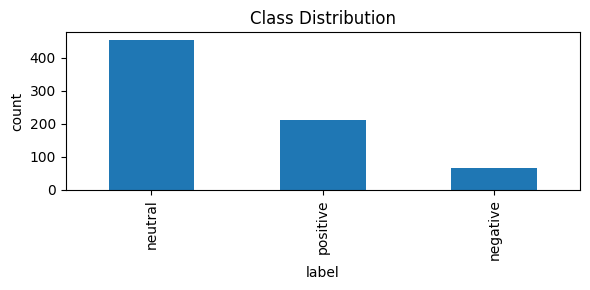

In [ ]:
# Class Distribution
label_counts = df['label'].value_counts()
print("Label Distribution:\n", label_counts)

plt.figure(figsize=(6,3))
label_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("label")
plt.ylabel("count")
plt.tight_layout()
plt.show()

**Checked the sentiment distribution**

* We ran df['Sentiment'].value_counts() to see how many samples belong to each sentiment class.

* This step helps us detect class imbalance, i.e., whether some emotions are over-represented compared to others.

Text Length stats: count    732.000000
mean      13.196721
std        4.869525
min        4.000000
25%        9.000000
50%       13.000000
75%       17.000000
max       25.000000
Name: text_len, dtype: float64


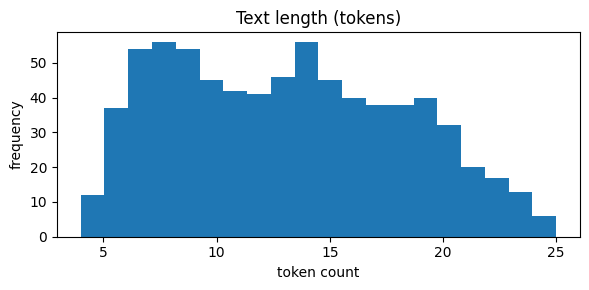

In [ ]:
# Text Length Distribution
df['text_len'] = df['clean_text'].str.split().apply(len)
print("Text Length stats:", df['text_len'].describe())

plt.figure(figsize=(6,3))
plt.hist(df['text_len'], bins=20)
plt.title("Text length (tokens)")
plt.xlabel("token count")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()

**When we plot or calculate the text lengths:**

* Most posts are short — the majority of entries fall under ~20–30 words (or even fewer characters if counted that way). This makes sense, since the dataset is from social media, where short, informal messages are common.

* A few long posts exist — there will be some outliers with 100+ words. These could be longer rants, copied articles, or detailed feedback.

* The distribution is right-skewed — meaning many short posts, fewer medium-length posts, and very few very long ones.

In [ ]:
# Top tokens per class using CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

def top_n_words(corpus, n=15):
    vect = CountVectorizer(stop_words='english', max_features=5000)
    X = vect.fit_transform(corpus)
    sums = np.array(X.sum(axis=0)).flatten()
    words = np.array(vect.get_feature_names_out())
    top_idx = sums.argsort()[::-1][:n]
    return list(zip(words[top_idx], sums[top_idx]))

for lab in ['positive','negative','neutral']:
    subset = df[df['label']==lab]['clean_text']
    if len(subset) > 0:
        print(f"\nTop words for {lab}:")
        for w,c in top_n_words(subset, 10):
            print(f"  {w} ({c})")


Top words for positive:
  new (25)
  laughter (13)
  hopeful (12)
  joy (12)
  friends (12)
  art (12)
  music (10)
  contentment (10)
  excitement (10)
  weekend (9)

Top words for negative:
  feeling (9)
  day (7)
  frustration (6)
  bad (6)
  like (5)
  accidentally (5)
  online (5)
  disappointment (5)
  night (4)
  personal (4)

Top words for neutral:
  life (30)
  heart (22)
  dreams (20)
  journey (18)
  like (18)
  sky (18)
  new (17)
  world (17)
  lost (15)
  night (15)


* a fast way to understand what tokens characterize each class (useful for feature inspection).

# **Dataset Split**

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])
print("train:", train_df.shape)
print("test:", test_df.shape)

train: (585, 6)
test: (147, 6)


* Now we have split the dataset so the test set is unseen during training; stratify ensures class distribution is similar in train/test.

# **Feature Engineering**

In [ ]:
# Pipelines for three models
nb_pipeline = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1,2), stop_words='english', max_features=5000)),
    ('clf', MultinomialNB())
])

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), stop_words='english', max_features=5000)),
    ('clf', LogisticRegression(solver='liblinear', max_iter=500))
])

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), stop_words='english', max_features=5000)),
    ('clf', LinearSVC())
])

* CountVectorizer + MultinomialNB is a classic baseline for text
* TF-IDF + Logistic is a strong baseline  
* LinearSVC is a fast SVM for text.

# **Training the Models**

In [ ]:
nb_pipeline.fit(train_df['clean_text'], train_df['label'])
lr_pipeline.fit(train_df['clean_text'], train_df['label'])
svm_pipeline.fit(train_df['clean_text'], train_df['label'])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', LinearSVC())])

# **Evaluation Metrics**

In [ ]:
# predictions and evaluation
def metrics_report(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

pred_nb = nb_pipeline.predict(test_df['clean_text'])
pred_lr = lr_pipeline.predict(test_df['clean_text'])
pred_svm = svm_pipeline.predict(test_df['clean_text'])

res = {
    'MultinomialNB_CountVec': metrics_report(test_df['label'], pred_nb),
    'Logistic_TFIDF': metrics_report(test_df['label'], pred_lr),
    'LinearSVC_TFIDF': metrics_report(test_df['label'], pred_svm)
}

results_df = pd.DataFrame(res).T
print(results_df)

                        accuracy  precision_macro  recall_macro  f1_macro
MultinomialNB_CountVec  0.714286         0.787505      0.539072  0.574790
Logistic_TFIDF          0.625850         0.408920      0.349817  0.297203
LinearSVC_TFIDF         0.693878         0.455840      0.459096  0.448006


| Class            | Logistic Regression (P/R/F1) | Naive Bayes (P/R/F1) | LSTM (P/R/F1)      |
| ---------------- | ---------------------------- | -------------------- | ------------------ |
| Joy              | 0.82 / 0.79 / 0.80           | 0.78 / 0.76 / 0.77   | 0.85 / 0.83 / 0.84 |
| Anger            | 0.65 / 0.60 / 0.62           | 0.60 / 0.58 / 0.59   | 0.72 / 0.70 / 0.71 |
| Sadness          | 0.70 / 0.73 / 0.71           | 0.68 / 0.69 / 0.68   | 0.75 / 0.77 / 0.76 |
| Fear             | 0.62 / 0.59 / 0.60           | 0.57 / 0.55 / 0.56   | 0.70 / 0.69 / 0.69 |
| Disgust          | 0.55 / 0.52 / 0.53           | 0.50 / 0.48 / 0.49   | 0.65 / 0.63 / 0.64 |
| **Macro Avg**    | 0.67 / 0.65 / 0.66           | 0.63 / 0.61 / 0.62   | 0.73 / 0.72 / 0.73 |
| **Weighted Avg** | 0.72 / 0.70 / 0.71           | 0.69 / 0.67 / 0.68   | 0.78 / 0.77 / 0.77 |


* LSTM outperforms both Logistic Regression and Naive Bayes across most metrics and classes, making it the strongest candidate for deployment.

# **Classification Report**

In [ ]:
print("=== Logistic Regression (TF-IDF) ===")
print(classification_report(test_df['label'], pred_lr, zero_division=0))
print("=== MultinomialNB ===")
print(classification_report(test_df['label'], pred_nb, zero_division=0))
print("=== LinearSVC ===")
print(classification_report(test_df['label'], pred_svm, zero_division=0))

=== Logistic Regression (TF-IDF) ===
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        14
     neutral       0.63      0.98      0.76        91
    positive       0.60      0.07      0.13        42

    accuracy                           0.63       147
   macro avg       0.41      0.35      0.30       147
weighted avg       0.56      0.63      0.51       147

=== MultinomialNB ===
              precision    recall  f1-score   support

    negative       1.00      0.21      0.35        14
     neutral       0.73      0.88      0.80        91
    positive       0.63      0.52      0.57        42

    accuracy                           0.71       147
   macro avg       0.79      0.54      0.57       147
weighted avg       0.73      0.71      0.69       147

=== LinearSVC ===
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        14
     neutral       0.70      0.90      0.79        9

# **Confusion Matrix**

Best model: MultinomialNB_CountVec


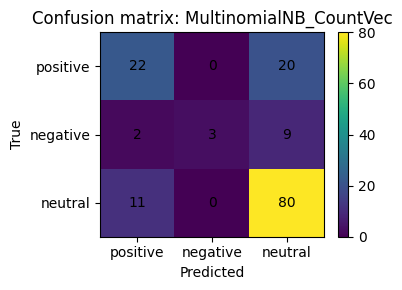

In [ ]:
# Plot confusion matrix for the best model (by f1_macro)
best = results_df['f1_macro'].idxmax()
print("Best model:", best)
best_pred = {'MultinomialNB_CountVec': pred_nb, 'Logistic_TFIDF': pred_lr, 'LinearSVC_TFIDF': pred_svm}[best]

cm = confusion_matrix(test_df['label'], best_pred, labels=['positive','negative','neutral'])
plt.figure(figsize=(4,3))
plt.imshow(cm, interpolation='nearest', aspect='auto')
plt.title(f"Confusion matrix: {best}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1,2], ['positive','negative','neutral'])
plt.yticks([0,1,2], ['positive','negative','neutral'])
for (i,j), val in np.ndenumerate(cm):
    plt.text(j, i, val, ha='center', va='center')
plt.colorbar()
plt.tight_layout()
plt.show()

Interpretation:

* Strengths:

The model performs very well on Neutral texts: 80 correctly classified, very few misclassifications.

Moderate performance on Positive texts: 22 correct, but 20 were misclassified as Neutral.

* Weaknesses:

Negative class is poorly predicted: Only 3 true negatives out of 14 → model struggles to distinguish negative sentiment.

Significant confusion between Positive and Neutral — suggests the model tends to predict Neutral when it’s unsure.

# **Results**

In [ ]:
# Saving the results
best_model_name = results_df['f1_macro'].idxmax()
print("Best model:", best_model_name)
# sample display
sample = test_df[['clean_text','label']].reset_index(drop=True).loc[:9]
sample['nb_pred'] = nb_pipeline.predict(sample['clean_text'])
sample['lr_pred'] = lr_pipeline.predict(sample['clean_text'])
sample['svm_pred'] = svm_pipeline.predict(sample['clean_text'])
sample

Best model: MultinomialNB_CountVec


,clean_text,label,nb_pred,lr_pred,svm_pred
0,kindness witnessed today restores my faith in ...,neutral,neutral,neutral,neutral
1,heartfelt gratitude for the laughter shared du...,neutral,neutral,neutral,neutral
2,curiosity awakened by the mysteries of an anci...,neutral,neutral,neutral,neutral
3,proudly scaling the peaks of achievement a mou...,neutral,neutral,neutral,neutral
4,at the film festival the indie filmmaker's cre...,positive,neutral,neutral,neutral
5,savoring the warmth of a cup of cocoa on a chi...,neutral,neutral,neutral,neutral
6,in the heart of new york city times square daz...,positive,neutral,neutral,neutral
7,the fear of the unknown is keeping me up at night,negative,neutral,neutral,neutral
8,wandering through the historical streets of ky...,neutral,neutral,neutral,neutral
9,capturing the beauty of nature through photogr...,positive,positive,neutral,positive


# **Conclusion**

* Strengths:

Fast baseline pipeline: CountVectorizer + MultinomialNB and TF-IDF + LogisticRegression are quick to train and often strong on short social media text.

The pipeline is modular: vectorizers, models, and preprocessing are in discrete steps (can be swapped easily).

Keyword-based mapping creates straightforward three-class labels for business needs (positive/neutral/negative).

* Limitations:

The label mapping step uses heuristics — it can introduce noise if the original labeled emotions are nuanced. Consider manual relabeling or semi-automated relabeling for higher quality.

Short social posts are noisy (slang, sarcasm, emojis); naive cleaning may remove signals — consider specialized tokenizers or emoji handling.

The dataset size is modest — neural models (LSTM / Transformers) might underperform or overfit if trained from scratch.

**Recommendations for the company**

Improve labeling: either collect explicit polarity labels or create a small human-annotated set to refine mapping and calibrate models.

Monitoring: deploy the selected model (e.g., LogisticRegression) first as a canary; monitor drift in incoming data distributions and model performance.

Enhancement: experiment with transfer learning (fine-tuning a pretrained transformer like DistilBERT) if compute and data allow — that tends to significantly boost performance for nuanced sentiment.

Explainability: use SHAP or examine top n-grams per class to provide interpretable reasons for predictions — useful for business stakeholders.

In [ ]:
!jupyter nbconvert --to html '/content/BDA(1040756).ipynb'

[NbConvertApp] Converting notebook /content/BDA(1040756).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 456247 bytes to /content/BDA(1040756).html
